<a href="https://www.kaggle.com/code/sonawanelalitsunil/spotify-global-streaming-trends-2024-ml-56?scriptVersionId=232716803" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spotify-global-streaming-data-2024/Spotify_2024_Global_Streaming_Data.csv


## Title: Spotify Global Streaming Trends 2024

### Description: A snapshot of Spotify's 2024 highlights—675M users, record $10B payouts, top artist Taylor Swift, and most-streamed song "Espresso" by Sabrina Carpenter.










## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/spotify-global-streaming-data-2024/Spotify_2024_Global_Streaming_Data.csv')

In [3]:
df.head()

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%)
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2019,23.10,3695.53,14240.35,4.28,Free,118.51,2.24
1,Brazil,The Weeknd,After Hours,R&B,2022,60.60,2828.16,11120.44,3.90,Premium,44.87,23.98
2,United States,Post Malone,Austin,Reggaeton,2023,42.84,1425.46,4177.49,4.03,Free,19.46,4.77
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2018,73.24,2704.33,12024.08,3.26,Premium,166.05,25.12
4,Italy,Ed Sheeran,Autumn Variations,R&B,2023,7.89,3323.25,13446.32,4.47,Free,173.43,15.82


In [4]:
df.tail()

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%)
495,Brazil,Karol G,MAÑANA SERÁ BONITO,Jazz,2018,18.80,2947.97,12642.83,3.59,Premium,83.30,18.58
496,Canada,Dua Lipa,Future Nostalgia,Classical,2023,89.68,4418.61,11843.46,3.15,Free,143.96,5.82
497,Germany,Karol G,MAÑANA SERÁ BONITO,Rock,2023,36.93,2642.90,8637.46,4.08,Free,76.36,15.84
498,Canada,SZA,SOS,Indie,2022,87.26,4320.23,12201.40,2.79,Free,84.50,13.07
499,Sweden,BTS,Proof,Reggaeton,2018,89.96,4804.15,12044.32,4.03,Free,92.27,34.36


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          500 non-null    object 
 1   Artist                           500 non-null    object 
 2   Album                            500 non-null    object 
 3   Genre                            500 non-null    object 
 4   Release Year                     500 non-null    int64  
 5   Monthly Listeners (Millions)     500 non-null    float64
 6   Total Streams (Millions)         500 non-null    float64
 7   Total Hours Streamed (Millions)  500 non-null    float64
 8   Avg Stream Duration (Min)        500 non-null    float64
 9   Platform Type                    500 non-null    object 
 10  Streams Last 30 Days (Millions)  500 non-null    float64
 11  Skip Rate (%)                    500 non-null    float64
dtypes: float64(6), int64(1

In [6]:
df.describe()

,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Streams Last 30 Days (Millions),Skip Rate (%)
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2020.488000,51.04122,2581.154080,8954.368880,3.520640,99.048500,20.370460
std,1.671959,28.23801,1416.055972,5167.648272,0.571431,57.533452,10.597202
min,2018.000000,1.01000,53.560000,184.300000,2.510000,2.850000,1.160000
25%,2019.000000,27.67250,1337.337500,4322.097500,3.030000,48.057500,11.152500
50%,2020.000000,50.82500,2697.355000,9053.665000,3.540000,101.465000,20.820000
75%,2022.000000,75.09500,3798.197500,12690.180000,4.000000,148.410000,28.760000
max,2023.000000,99.80000,4985.540000,21874.920000,4.490000,200.000000,39.970000


In [7]:
df.isnull().sum()

Country                            0
Artist                             0
Album                              0
Genre                              0
Release Year                       0
Monthly Listeners (Millions)       0
Total Streams (Millions)           0
Total Hours Streamed (Millions)    0
Avg Stream Duration (Min)          0
Platform Type                      0
Streams Last 30 Days (Millions)    0
Skip Rate (%)                      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(500, 12)

In [10]:
df.dtypes

Country                             object
Artist                              object
Album                               object
Genre                               object
Release Year                         int64
Monthly Listeners (Millions)       float64
Total Streams (Millions)           float64
Total Hours Streamed (Millions)    float64
Avg Stream Duration (Min)          float64
Platform Type                       object
Streams Last 30 Days (Millions)    float64
Skip Rate (%)                      float64
dtype: object

In [11]:
df.columns

Index(['Country', 'Artist', 'Album', 'Genre', 'Release Year',
       'Monthly Listeners (Millions)', 'Total Streams (Millions)',
       'Total Hours Streamed (Millions)', 'Avg Stream Duration (Min)',
       'Platform Type', 'Streams Last 30 Days (Millions)', 'Skip Rate (%)'],
      dtype='object')

## Data visualizations

Text(0.5, 1.0, 'Total Streams by Genre and Platform')

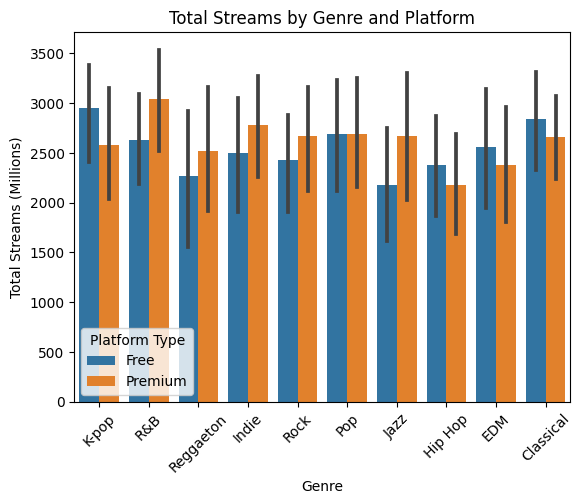

In [12]:
sns.barplot(data=df, x='Genre', y='Total Streams (Millions)', hue='Platform Type')
plt.xticks(rotation=45)
plt.title('Total Streams by Genre and Platform')

Text(0.5, 1.0, 'Top 10 Streaming Countries')

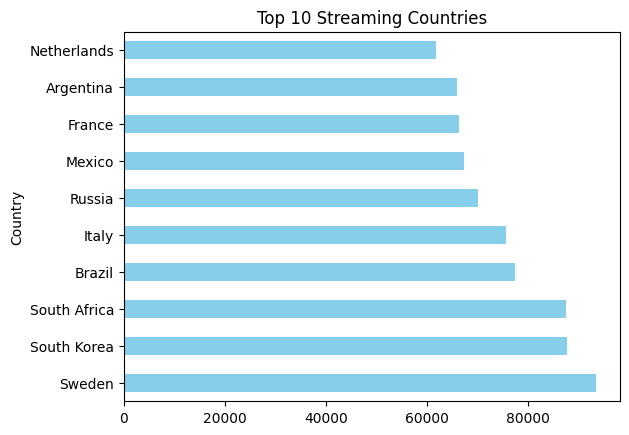

In [13]:
top_countries = df.groupby('Country')['Total Streams (Millions)'].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind='barh', color='skyblue')
plt.title('Top 10 Streaming Countries')

Text(0.5, 1.0, 'Top 10 Artists by Monthly Listeners')

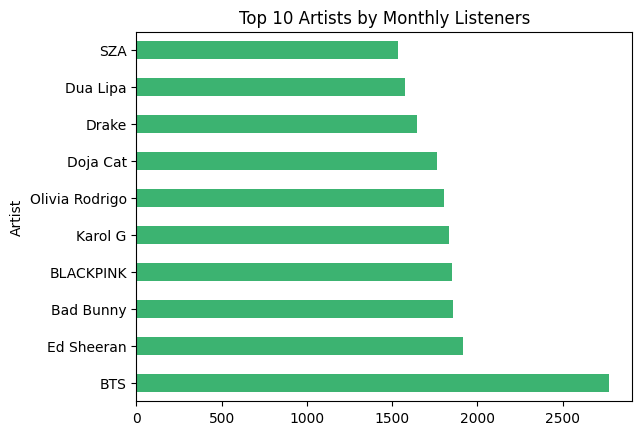

In [14]:
top_artists = df.groupby('Artist')['Monthly Listeners (Millions)'].sum().sort_values(ascending=False).head(10)
top_artists.plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Artists by Monthly Listeners')

Text(0.5, 1.0, 'Streaming Trends by Album Release Year')

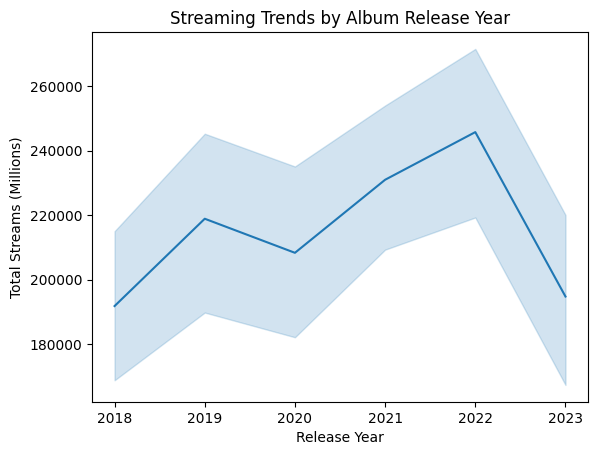

In [15]:
sns.lineplot(data=df, x='Release Year', y='Total Streams (Millions)', estimator='sum')
plt.title('Streaming Trends by Album Release Year')

Text(0.5, 1.0, 'Distribution of Average Stream Duration')

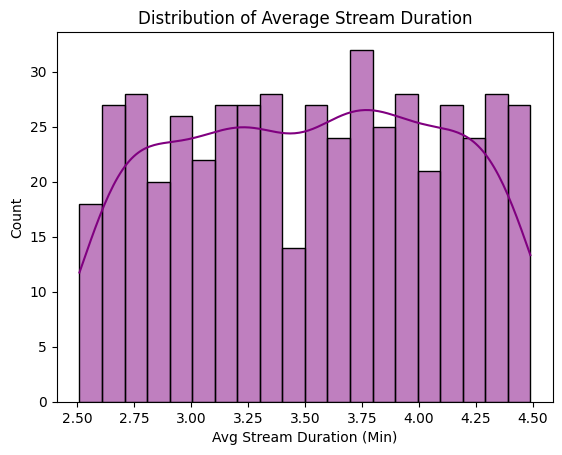

In [16]:
sns.histplot(df['Avg Stream Duration (Min)'], bins=20, kde=True, color='purple')
plt.title('Distribution of Average Stream Duration')


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'K-pop'),
  Text(1, 0, 'R&B'),
  Text(2, 0, 'Reggaeton'),
  Text(3, 0, 'Indie'),
  Text(4, 0, 'Rock'),
  Text(5, 0, 'Pop'),
  Text(6, 0, 'Jazz'),
  Text(7, 0, 'Hip Hop'),
  Text(8, 0, 'EDM'),
  Text(9, 0, 'Classical')])

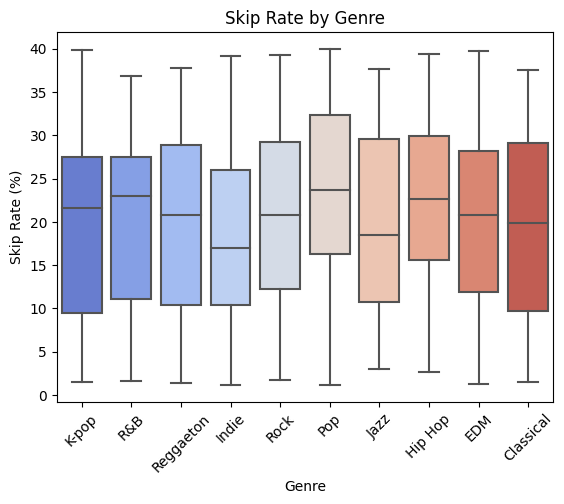

In [17]:
sns.boxplot(data=df, x='Genre', y='Skip Rate (%)', palette='coolwarm')
plt.title('Skip Rate by Genre')
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Correlation Matrix')

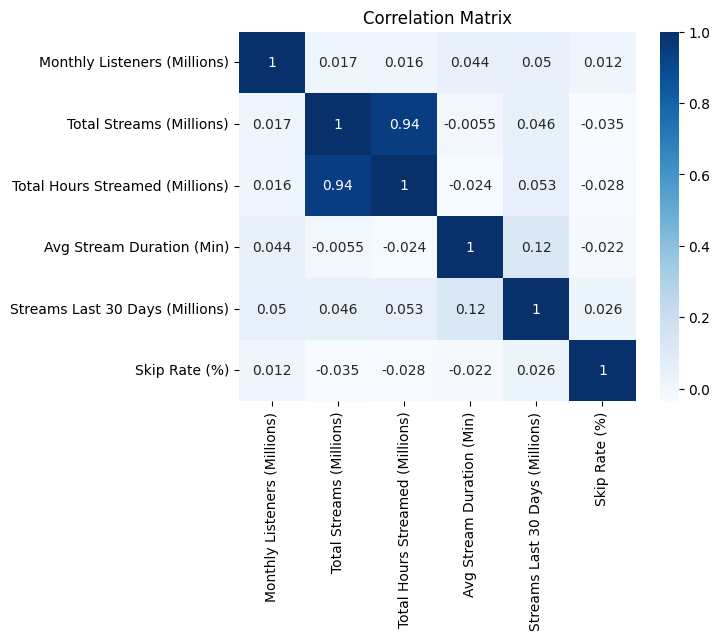

In [18]:
numeric_cols = ['Monthly Listeners (Millions)', 'Total Streams (Millions)',
                'Total Hours Streamed (Millions)', 'Avg Stream Duration (Min)', 
                'Streams Last 30 Days (Millions)', 'Skip Rate (%)']

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')


Text(0.5, 1.0, 'Current Trends vs All-Time Streams')

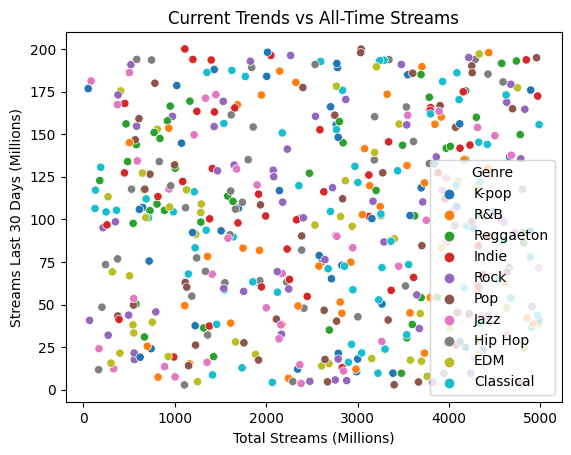

In [19]:
sns.scatterplot(data=df, x='Total Streams (Millions)', y='Streams Last 30 Days (Millions)', hue='Genre')
plt.title('Current Trends vs All-Time Streams')


(array([0, 1]), [Text(0, 0, 'Free'), Text(1, 0, 'Premium')])

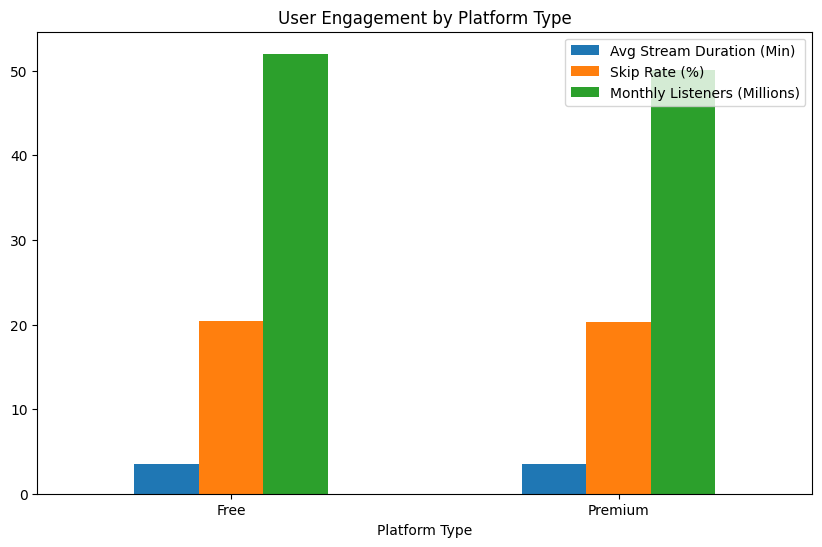

In [20]:
metrics = ['Avg Stream Duration (Min)', 'Skip Rate (%)', 'Monthly Listeners (Millions)']
df.groupby('Platform Type')[metrics].mean().plot(kind='bar', figsize=(10, 6))
plt.title('User Engagement by Platform Type')
plt.xticks(rotation=0)


## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [22]:
df = df.dropna()

In [23]:
# Label Encode categorical columns
le = LabelEncoder()
for col in ['Country', 'Artist', 'Album', 'Genre', 'Platform Type']:
    df[col] = le.fit_transform(df[col])


In [24]:
# Define features and target
X = df.drop('Platform Type', axis=1)
y = df['Platform Type']


In [25]:
# --- Step 2: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# --- Step 3: ML Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [27]:
results = {}

In [28]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = round(acc * 100, 2)


In [29]:
# --- Step 4: Confusion Matrix for Best Model ---
best_model = max(results, key=results.get)
best_preds = models[best_model].predict(X_test)
cm = confusion_matrix(y_test, best_preds)


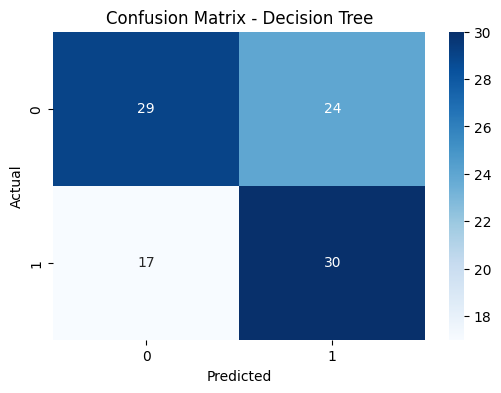

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [31]:
print("📊 Accuracy Results:")
for model, acc in results.items():
    print(f"{model}: {acc}%")

📊 Accuracy Results:
Logistic Regression: 35.0%
Decision Tree: 59.0%
Random Forest: 46.0%
KNN: 46.0%
SVM: 45.0%
Gradient Boosting: 50.0%


## Thank you...pls upvote!!!!